In [13]:
# ══════════════════════════════════════════════════════════════════════
# CELL 1 — Setup, imports, constants, fold definitions, all utilities
#
# Runtime → Change runtime type → T4 GPU  (NOT TPU)
# Estimated total runtime: ~90–120 minutes
# ══════════════════════════════════════════════════════════════════════
import subprocess, sys
for pkg in ["ultralytics", "timm", "scikit-learn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import torch
assert torch.cuda.is_available(), "Go to Runtime → Change runtime type → T4 GPU"
print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
DEVICE = "cuda"

import cv2, math, random, shutil, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.model_selection import KFold
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import timm
from ultralytics import YOLO

from google.colab import drive
drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────────────────
DRIVE_ROOT  = Path('/content/drive/MyDrive/zeon-tubes')
DATASET_DIR = DRIVE_ROOT / 'Dataset'
IMAGES_DIR  = DATASET_DIR / 'images'
ANN_CSV     = DATASET_DIR / 'annotations.csv'
OUTPUTS     = Path('/content/zeon_final')
LOCAL_IMGS  = Path('/content/tube_images')   # fast local copy for YOLO
OUTPUTS.mkdir(exist_ok=True)

assert IMAGES_DIR.exists(), f"Not found: {IMAGES_DIR}"
assert ANN_CSV.exists(),    f"Not found: {ANN_CSV}"

# ── Constants ──────────────────────────────────────────────────────────
IMG_W, IMG_H  = 640, 480
CROP_SIZE     = 128
N_BINS        = 36
BIN_SIZE      = 360.0 / N_BINS
N_FOLDS       = 5
DIST_THRESH   = 30       # px — detection is TP if within this of GT centre
YOLO_EPOCHS   = 60
ANGLE_EPOCHS  = 60
BATCH         = 32
CONF_THRESH   = 0.25

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

random.seed(42); np.random.seed(42); torch.manual_seed(42)

# ── Load annotations ───────────────────────────────────────────────────
df         = pd.read_csv(ANN_CSV)
ALL_IMAGES = sorted(df['image'].unique().tolist())
print(f"  {len(df)} annotations | {len(ALL_IMAGES)} images | "
      f"{df['image'].value_counts().mean():.1f} tubes/image avg")

# ── Copy images to local SSD for fast YOLO I/O ────────────────────────
# Drive-backed paths are slow for repeated reads during YOLO training.
LOCAL_IMGS.mkdir(exist_ok=True)
missing = [n for n in ALL_IMAGES if not (LOCAL_IMGS/n).exists()]
if missing:
    print(f"  Copying {len(missing)} images to local SSD …")
    for name in missing:
        shutil.copy(IMAGES_DIR/name, LOCAL_IMGS/name)
print(f"  ✅ {len(ALL_IMAGES)} images ready at {LOCAL_IMGS}")

# ── 5-fold image-level splits (shared by Stage 1 and Stage 2) ─────────
kf    = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
FOLDS = [([ALL_IMAGES[i] for i in tr], [ALL_IMAGES[i] for i in va])
         for tr, va in kf.split(ALL_IMAGES)]
print(f"  Folds: {[(len(t),len(v)) for t,v in FOLDS]}  (train, val images)")

# ══════════════════════════════════════════════════════════════════════
# Shared utilities
# ══════════════════════════════════════════════════════════════════════

# ── Image / crop helpers ───────────────────────────────────────────────
def load_bgr(name, local=False):
    d = LOCAL_IMGS if local else IMAGES_DIR
    return cv2.imread(str(d / name))

def load_rgb(name):
    return cv2.cvtColor(load_bgr(name), cv2.COLOR_BGR2RGB)

def extract_crop(img_bgr, cx, cy, bw, bh, size=CROP_SIZE, pad_factor=1.5):
    """
    Square crop centred on (cx, cy).
    Size = diagonal(bbox) × pad_factor; reflects at image boundaries.
    """
    half = max(int(math.hypot(bw, bh) / 2 * pad_factor), 24)
    pad  = max(0, half - int(cx), half - int(cy),
               int(cx) + half - IMG_W + 1,
               int(cy) + half - IMG_H + 1)
    if pad > 0:
        img_bgr = cv2.copyMakeBorder(img_bgr, pad, pad, pad, pad,
                                     cv2.BORDER_REFLECT)
    cx_p, cy_p = int(cx)+pad, int(cy)+pad
    crop = img_bgr[cy_p-half : cy_p+half, cx_p-half : cx_p+half]
    if crop.size == 0:
        crop = np.zeros((size, size, 3), dtype=np.uint8)
    return cv2.resize(crop, (size, size))

# ── Angle helpers ──────────────────────────────────────────────────────
def sincos_to_angle(s, c):
    return math.degrees(math.atan2(s, c)) % 360.0

def circular_err(pred, gt):
    return abs(((pred - gt + 180) % 360) - 180)

def compute_stats(errors):
    e = np.array(errors)
    if len(e) == 0:
        return dict(MAE=0, Median=0, pct15=0, pct30=0, flips=0, errors=e)
    return dict(MAE    = np.mean(e),
                Median = np.median(e),
                pct15  = np.mean(e<=15)*100,
                pct30  = np.mean(e<=30)*100,
                flips  = np.mean(e>150)*100,
                errors = e)

# ── Detection metrics ──────────────────────────────────────────────────
def match_and_score(gt_centers, det_centers, thresh=DIST_THRESH):
    """
    Greedy nearest-neighbour matching between GT and detected centres.
    Returns: tp, fp, fn, matched_pairs [(gi, di), …]
    """
    matched_gt  = [False] * len(gt_centers)
    matched_det = [False] * len(det_centers)
    pairs = []
    cands = sorted([
        (math.hypot(gt_centers[gi][0]-det_centers[di][0],
                    gt_centers[gi][1]-det_centers[di][1]), gi, di)
        for gi in range(len(gt_centers))
        for di in range(len(det_centers))
    ])
    for dist, gi, di in cands:
        if dist >= thresh: break
        if matched_gt[gi] or matched_det[di]: continue
        matched_gt[gi] = matched_det[di] = True
        pairs.append((gi, di))
    tp = len(pairs)
    fp = matched_det.count(False)
    fn = matched_gt.count(False)
    return tp, fp, fn, pairs

def prf(tp, fp, fn):
    p  = tp / (tp+fp) if (tp+fp) > 0 else 0.0
    r  = tp / (tp+fn) if (tp+fn) > 0 else 0.0
    f1 = 2*p*r / (p+r) if (p+r) > 0 else 0.0
    return p, r, f1

# ── YOLO OBB label writer ──────────────────────────────────────────────
def write_obb_labels(label_dir, image_list):
    """Write Ultralytics OBB polygon labels: '0 x1 y1 … x4 y4'"""
    for name in image_list:
        rows = df[df['image'] == name]
        with open(label_dir / (Path(name).stem + '.txt'), 'w') as f:
            for _, r in rows.iterrows():
                rect = ((float(r['center_x']), float(r['center_y'])),
                        (float(r['bbox_w']),   float(r['bbox_h'])),
                        float(r['bbox_rotation']))
                pts = cv2.boxPoints(rect)
                pts[:, 0] = np.clip(pts[:, 0] / IMG_W, 0, 1)
                pts[:, 1] = np.clip(pts[:, 1] / IMG_H, 0, 1)
                f.write('0 ' + ' '.join(f'{v:.6f}' for v in pts.flatten()) + '\n')

# ── YOLO inference ─────────────────────────────────────────────────────
def yolo_detect(model, img_name, conf=CONF_THRESH):
    """Returns list of dicts {cx, cy, w, h} for each detection (pixels)."""
    res = model(str(LOCAL_IMGS / img_name), conf=conf, verbose=False)[0]
    if res.obb is None or len(res.obb) == 0:
        return []
    return [{'cx': float(x[0]), 'cy': float(x[1]),
             'w':  float(x[2]), 'h':  float(x[3])}
            for x in res.obb.xywhr.cpu().numpy()]

# ── Model D: BinnedNet ─────────────────────────────────────────────────
class BinnedNet(nn.Module):
    def __init__(self, n_bins=N_BINS):
        super().__init__()
        base = timm.create_model('mobilenetv3_small_100',
                                  pretrained=True, num_classes=0)
        # Dummy pass to get the true output dimension — avoids the
        # num_features vs actual-output mismatch in MobileNetV3.
        with torch.no_grad():
            fdim = base(torch.zeros(1, 3, CROP_SIZE, CROP_SIZE)).shape[1]
        self.base = base
        self.cls  = nn.Linear(fdim, n_bins)
        self.reg  = nn.Linear(fdim, n_bins)

    def forward(self, x):
        f = self.base(x)
        return self.cls(f), self.reg(f)

# ── Crop dataset ───────────────────────────────────────────────────────
class TubeDataset(Dataset):
    """(crop_bgr, angle_deg) with geometry-correct augmentation."""
    def __init__(self, samples, augment=True):
        self.samples = samples
        self.augment = augment

    def __len__(self): return len(self.samples)

    def _jitter(self, img):
        img = img.astype(np.float32)
        if random.random() < 0.6:
            img = np.clip(img + random.uniform(-40, 40), 0, 255)
        if random.random() < 0.5:
            a   = random.uniform(0.6, 1.4)
            img = np.clip((img - img.mean())*a + img.mean(), 0, 255)
        if random.random() < 0.3:
            img = np.clip(img + np.random.randn(*img.shape).astype(np.float32)*12,
                          0, 255)
        return img.astype(np.uint8)

    def __getitem__(self, idx):
        crop_bgr, angle = self.samples[idx]
        crop = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB).copy()
        if self.augment:
            if random.random() < 0.5:
                crop  = crop[:, ::-1].copy(); angle = (180 - angle) % 360
            if random.random() < 0.5:
                crop  = crop[::-1].copy();    angle = (360 - angle) % 360
            k = random.randint(0, 3)
            if k:
                crop  = np.rot90(crop, k).copy(); angle = (angle + 90*k) % 360
            crop = self._jitter(crop)
        img = (crop.astype(np.float32)/255.0 - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(img.transpose(2, 0, 1))
        return (img,
                torch.tensor(angle,                dtype=torch.float32),
                torch.tensor(int(angle/BIN_SIZE) % N_BINS, dtype=torch.long),
                torch.tensor((angle % BIN_SIZE) / BIN_SIZE, dtype=torch.float32))

def build_crops(image_list):
    out = []
    for name in image_list:
        img = load_bgr(name)
        for _, r in df[df['image']==name].iterrows():
            crop = extract_crop(img, r['center_x'], r['center_y'],
                                r['bbox_w'], r['bbox_h'])
            out.append((crop, float(r['angle_deg'])))
    return out

def make_loaders(tr_s, va_s):
    tl = DataLoader(TubeDataset(tr_s, True),  BATCH, shuffle=True,
                    num_workers=2, pin_memory=True)
    vl = DataLoader(TubeDataset(va_s, False), BATCH, shuffle=False,
                    num_workers=2, pin_memory=True)
    return tl, vl

def train_angle_model(model, tl, vl):
    opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, ANGLE_EPOCHS)
    best_mae, best_state = float('inf'), None
    for ep in range(1, ANGLE_EPOCHS+1):
        model.train()
        for img, _, bi, off in tl:
            img, bi, off = img.to(DEVICE), bi.to(DEVICE), off.to(DEVICE)
            logits, offsets = model(img)
            B   = len(bi)
            loss = F.cross_entropy(logits, bi) + \
                   F.mse_loss(offsets[torch.arange(B), bi], off)
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        mae = eval_angle_model(model, vl)['MAE']
        if mae < best_mae:
            best_mae   = mae
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model

@torch.no_grad()
def eval_angle_model(model, loader):
    model.eval()
    errs = []
    for img, gt_angles, _, _ in loader:
        logits, offsets = model(img.to(DEVICE))
        logits, offsets = logits.cpu(), offsets.cpu()
        bp   = logits.argmax(1)
        B    = len(bp)
        op   = offsets[torch.arange(B), bp].clamp(0, 1)
        pred = (bp.float()*BIN_SIZE + op*BIN_SIZE) % 360
        errs.extend(torch.abs(((pred - gt_angles + 180) % 360) - 180).tolist())
    return compute_stats(errs)

@torch.no_grad()
def predict_angle_single(model, crop_bgr):
    """Single crop BGR → predicted angle in degrees."""
    model.eval()
    crop = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    crop = (crop - IMAGENET_MEAN) / IMAGENET_STD
    t    = torch.from_numpy(crop.transpose(2,0,1)).unsqueeze(0).to(DEVICE)
    logits, offsets = model(t)
    bp = logits.cpu().argmax(1)[0].item()
    op = offsets.cpu()[0, bp].clamp(0, 1).item()
    return (bp * BIN_SIZE + op * BIN_SIZE) % 360.0

def draw_angle_arrow(ax, cx, cy, angle_deg, color, length=34, lw=2.5):
    r = math.radians(angle_deg)
    ax.annotate('', xy=(cx + length*math.cos(r), cy - length*math.sin(r)),
                xytext=(cx, cy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))

print("✅ Cell 1 complete — all utilities ready")

✅ GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  371 annotations | 70 images | 5.3 tubes/image avg
  ✅ 70 images ready at /content/tube_images
  Folds: [(56, 14), (56, 14), (56, 14), (56, 14), (56, 14)]  (train, val images)
✅ Cell 1 complete — all utilities ready



════════════════════════════════════════════════════════════
  STAGE 1 | FOLD 1/5  train=56 val=14 images
════════════════════════════════════════════════════════════
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_folds/fold0/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

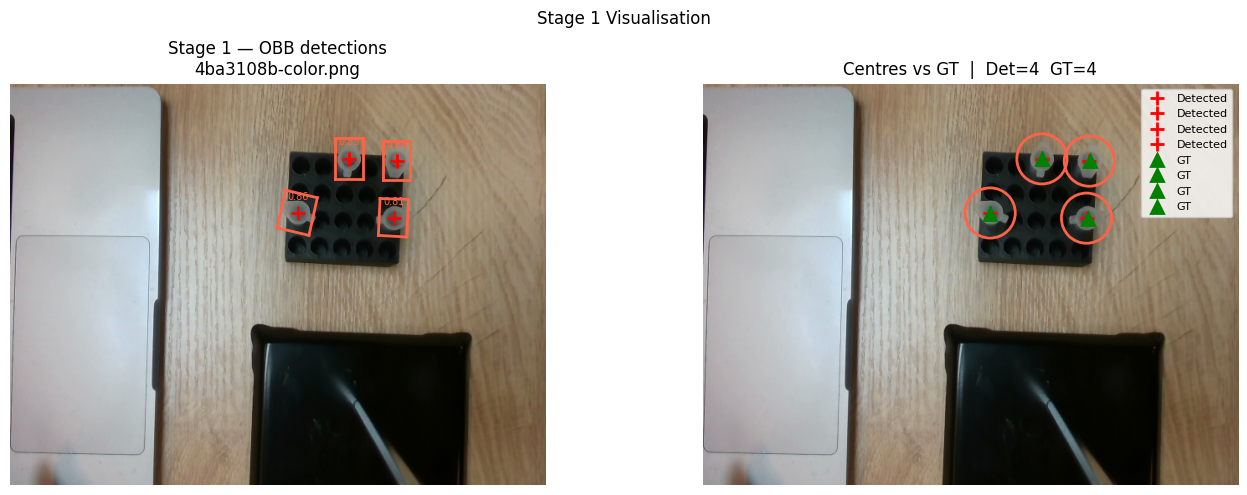

✅ Stage 1 complete | → /content/zeon_final/stage1_sample.png


In [11]:
# ══════════════════════════════════════════════════════════════════════
# CELL 2 — STAGE 1: 5-fold YOLOv11n-OBB detection training + evaluation
# ~60–90 minutes on T4
# ══════════════════════════════════════════════════════════════════════
YOLO_ROOT = Path('/content/yolo_folds')

yolo_weights   = {}   # fi → weights path string
s1_fold_metrics = []  # fi → {P, R, F1, TP, FP, FN}

for fi, (train_imgs, val_imgs) in enumerate(FOLDS):
    print(f"\n{'═'*60}")
    print(f"  STAGE 1 | FOLD {fi+1}/{N_FOLDS}  "
          f"train={len(train_imgs)} val={len(val_imgs)} images")
    print(f"{'═'*60}")

    # ── Build fold dataset ────────────────────────────────────────────
    fd = YOLO_ROOT / f'fold{fi}'
    for split, imgs in [('train', train_imgs), ('val', val_imgs)]:
        img_d = fd / 'images' / split
        lbl_d = fd / 'labels' / split
        img_d.mkdir(parents=True, exist_ok=True)
        lbl_d.mkdir(parents=True, exist_ok=True)
        for name in imgs:
            dst = img_d / name
            if not dst.exists():
                os.symlink(str((LOCAL_IMGS / name).resolve()), str(dst))
        write_obb_labels(lbl_d, imgs)

    (fd / 'data.yaml').write_text(
        f"path: {fd}\ntrain: images/train\nval: images/val\n"
        f"nc: 1\nnames: ['tube']\n"
    )

    # ── Train ─────────────────────────────────────────────────────────
    m = YOLO('yolo11n-obb.pt')
    m.train(
        data       = str(fd / 'data.yaml'),
        epochs     = YOLO_EPOCHS,
        imgsz      = 640,
        batch      = 16,
        device     = 0,
        project    = str(OUTPUTS / 'yolo_runs'),
        name       = f'fold{fi}',
        exist_ok   = True,
        patience   = 15,
        flipud     = 0.5,  fliplr     = 0.5,
        hsv_h      = 0.015, hsv_s     = 0.7,  hsv_v = 0.4,
        mosaic     = 1.0,  copy_paste = 0.2,
        workers    = 2,    verbose    = False,
    )
    w = OUTPUTS/'yolo_runs'/f'fold{fi}'/'weights'/'best.pt'
    if not w.exists():
        w = OUTPUTS/'yolo_runs'/f'fold{fi}'/'weights'/'last.pt'
    yolo_weights[fi] = str(w)

    # ── Evaluate detection on val images ──────────────────────────────
    inf = YOLO(str(w))
    tp = fp = fn = 0
    for name in val_imgs:
        dets  = yolo_detect(inf, name)
        gt_c  = [(float(r['center_x']), float(r['center_y']))
                 for _, r in df[df['image']==name].iterrows()]
        det_c = [(d['cx'], d['cy']) for d in dets]
        t, f, n, _ = match_and_score(gt_c, det_c)
        tp += t; fp += f; fn += n

    p, r, f1 = prf(tp, fp, fn)
    s1_fold_metrics.append({'fold':fi+1, 'P':p, 'R':r, 'F1':f1,
                             'TP':tp, 'FP':fp, 'FN':fn})
    print(f"  P={p:.3f}  R={r:.3f}  F1={f1:.3f}  "
          f"TP={tp}  FP={fp}  FN={fn}")
    del m, inf; torch.cuda.empty_cache()

# ── Stage 1 fold summary ──────────────────────────────────────────────
s1_df = pd.DataFrame(s1_fold_metrics)
print(f"\n{'─'*55}")
print(f"  STAGE 1 SUMMARY — YOLOv11n-OBB (5-fold CV)")
print(f"{'─'*55}")
print(s1_df.to_string(index=False))
print(f"\n  Mean  P={s1_df.P.mean():.3f}±{s1_df.P.std():.3f}"
      f"   R={s1_df.R.mean():.3f}±{s1_df.R.std():.3f}"
      f"   F1={s1_df.F1.mean():.3f}±{s1_df.F1.std():.3f}")
print(f"{'─'*55}")

# ── Visualise detection on a random val image from fold 0 ─────────────
sample_name = random.choice(FOLDS[0][1])
inf0  = YOLO(yolo_weights[0])
dets0 = yolo_detect(inf0, sample_name)
gt_c0 = [(float(r['center_x']), float(r['center_y']))
          for _, r in df[df['image']==sample_name].iterrows()]

img_rgb = load_rgb(sample_name)
res0    = inf0(str(LOCAL_IMGS/sample_name), conf=CONF_THRESH, verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax in axes: ax.imshow(img_rgb); ax.axis('off')

# Left: OBB polygons
axes[0].set_title(f'Stage 1 — OBB detections\n{sample_name}')
if res0.obb is not None and len(res0.obb) > 0:
    for xywhr, cf in zip(res0.obb.xywhr.cpu().numpy(),
                          res0.obb.conf.cpu().numpy()):
        cx, cy, w, h, ang = xywhr
        pts = cv2.boxPoints(((cx,cy),(w,h), math.degrees(ang))).astype(int)
        for j in range(4):
            p1, p2 = tuple(pts[j]), tuple(pts[(j+1)%4])
            axes[0].plot([p1[0],p2[0]], [p1[1],p2[1]], 'tomato', lw=2)
        axes[0].plot(cx, cy, 'r+', ms=10, mew=2)
        axes[0].text(cx, cy-16, f'{cf:.2f}', color='tomato',
                     fontsize=7, ha='center')

# Right: centres vs GT
for cx, cy in [(d['cx'],d['cy']) for d in dets0]:
    axes[1].add_patch(plt.Circle((cx,cy), DIST_THRESH,
                                 color='tomato', fill=False, lw=2))
    axes[1].plot(cx, cy, 'r+', ms=10, mew=2, label='Detected')
for gx, gy in gt_c0:
    axes[1].plot(gx, gy, 'g^', ms=9, mew=2, label='GT')
axes[1].set_title(f'Centres vs GT  |  Det={len(dets0)}  GT={len(gt_c0)}')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('Stage 1 Visualisation', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS/'stage1_sample.png', dpi=120, bbox_inches='tight')
plt.show()
del inf0; torch.cuda.empty_cache()
print(f"✅ Stage 1 complete | → {OUTPUTS/'stage1_sample.png'}")


════════════════════════════════════════════════════════════
  STAGE 2 | FOLD 1/5  train crops=301  val crops=70
════════════════════════════════════════════════════════════
  MAE=2.9°  Med=2.1°  ≤15°=100.0%  Flips=0.0%

════════════════════════════════════════════════════════════
  STAGE 2 | FOLD 2/5  train crops=297  val crops=74
════════════════════════════════════════════════════════════
  MAE=2.6°  Med=1.8°  ≤15°=100.0%  Flips=0.0%

════════════════════════════════════════════════════════════
  STAGE 2 | FOLD 3/5  train crops=292  val crops=79
════════════════════════════════════════════════════════════
  MAE=2.8°  Med=2.1°  ≤15°=100.0%  Flips=0.0%

════════════════════════════════════════════════════════════
  STAGE 2 | FOLD 4/5  train crops=298  val crops=73
════════════════════════════════════════════════════════════
  MAE=2.5°  Med=1.8°  ≤15°=100.0%  Flips=0.0%

════════════════════════════════════════════════════════════
  STAGE 2 | FOLD 5/5  train crops=296  val crops=75
══

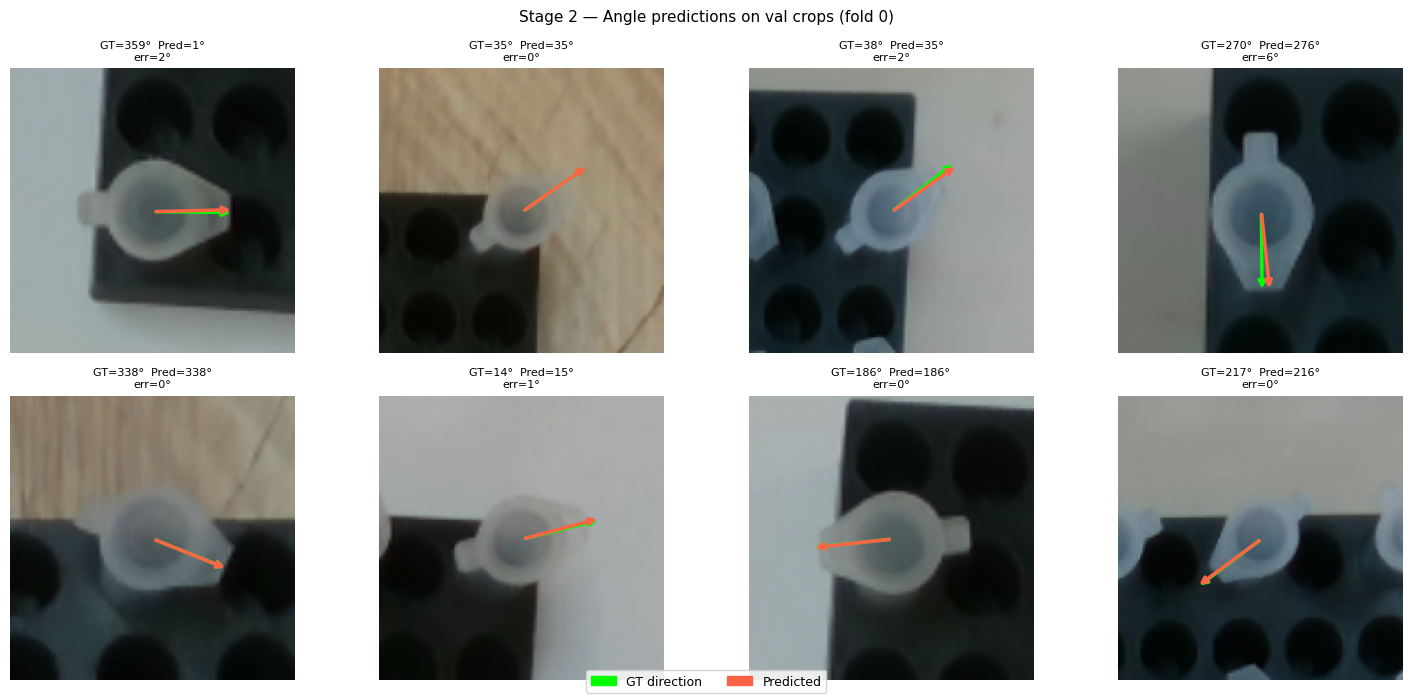

✅ Stage 2 complete | → /content/zeon_final/stage2_sample.png


In [14]:
# ══════════════════════════════════════════════════════════════════════
# CELL 3 — STAGE 2: 5-fold Model D (Binned+offset) on GT crops
# ~35–50 minutes on T4
# ══════════════════════════════════════════════════════════════════════
angle_weights  = {}   # fi → weights path string
s2_fold_stats  = []   # fi → compute_stats result

for fi, (train_imgs, val_imgs) in enumerate(FOLDS):
    print(f"\n{'═'*60}")
    n_tr = sum(len(df[df['image']==n]) for n in train_imgs)
    n_va = sum(len(df[df['image']==n]) for n in val_imgs)
    print(f"  STAGE 2 | FOLD {fi+1}/{N_FOLDS}  "
          f"train crops={n_tr}  val crops={n_va}")
    print(f"{'═'*60}")

    tr_s = build_crops(train_imgs)
    va_s = build_crops(val_imgs)
    tl, vl = make_loaders(tr_s, va_s)

    model = BinnedNet().to(DEVICE)
    model = train_angle_model(model, tl, vl)

    stats = eval_angle_model(model, vl)
    s2_fold_stats.append(stats)
    print(f"  MAE={stats['MAE']:.1f}°  Med={stats['Median']:.1f}°  "
          f"≤15°={stats['pct15']:.1f}%  Flips={stats['flips']:.1f}%")

    w = OUTPUTS / f'angle_fold{fi}.pt'
    torch.save(model.state_dict(), w)
    angle_weights[fi] = str(w)
    del model; torch.cuda.empty_cache()

# ── Stage 2 fold summary ──────────────────────────────────────────────
maes = [s['MAE']    for s in s2_fold_stats]
meds = [s['Median'] for s in s2_fold_stats]
p15s = [s['pct15']  for s in s2_fold_stats]
p30s = [s['pct30']  for s in s2_fold_stats]
flps = [s['flips']  for s in s2_fold_stats]

print(f"\n{'─'*60}")
print(f"  STAGE 2 SUMMARY — Binned+offset angle head (5-fold CV)")
print(f"{'─'*60}")
for fi, s in enumerate(s2_fold_stats):
    print(f"  Fold {fi+1}  MAE={s['MAE']:.1f}°  Med={s['Median']:.1f}°  "
          f"≤15°={s['pct15']:.1f}%  Flips={s['flips']:.1f}%")
print(f"\n  Mean  MAE={np.mean(maes):.1f}°±{np.std(maes):.1f}°"
      f"  Med={np.mean(meds):.1f}°±{np.std(meds):.1f}°"
      f"  ≤15°={np.mean(p15s):.1f}%±{np.std(p15s):.1f}%"
      f"  Flips={np.mean(flps):.1f}%±{np.std(flps):.1f}%")
print(f"{'─'*60}")

# ── Visualise angle predictions on 8 random val crops from fold 0 ─────
m0  = BinnedNet().to(DEVICE)
m0.load_state_dict(torch.load(angle_weights[0], map_location=DEVICE,
                               weights_only=False))

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
fig.suptitle('Stage 2 — Angle predictions on val crops (fold 0)', fontsize=11)
va_s0 = build_crops(FOLDS[0][1])
for ax, (crop_bgr, gt_angle) in zip(axes.flat, random.sample(va_s0, 8)):
    pred_angle = predict_angle_single(m0, crop_bgr)
    err        = circular_err(pred_angle, gt_angle)
    crop_rgb   = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(crop_rgb); ax.axis('off')
    cx = cy = CROP_SIZE // 2
    draw_angle_arrow(ax, cx, cy, gt_angle,   'lime',   length=36)
    draw_angle_arrow(ax, cx, cy, pred_angle, 'tomato', length=36)
    ax.set_title(f'GT={gt_angle:.0f}°  Pred={pred_angle:.0f}°\nerr={err:.0f}°',
                 fontsize=8, color='tomato' if err > 30 else 'black')

handles = [mpatches.Patch(color='lime',   label='GT direction'),
           mpatches.Patch(color='tomato', label='Predicted')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS/'stage2_sample.png', dpi=120, bbox_inches='tight')
plt.show()
del m0; torch.cuda.empty_cache()
print(f"✅ Stage 2 complete | → {OUTPUTS/'stage2_sample.png'}")

In [15]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4 — END-TO-END: YOLO detection → Model D angle estimation
#
# For each fold, uses that fold's weights for both models.
# Crops are extracted from YOLO-detected box centres and dimensions
# (not from GT) — this is the honest end-to-end condition.
# ══════════════════════════════════════════════════════════════════════
e2e_records = []   # one row per tube per image (TP, FP, and FN)

e2e_tp = e2e_fp = e2e_fn = 0
e2e_ang_errors = []

for fi, (_, val_imgs) in enumerate(FOLDS):
    print(f"  Fold {fi+1}/{N_FOLDS} — YOLO+Model D on {len(val_imgs)} val images …",
          end='', flush=True)

    # Load fold-matched models
    yolo_m  = YOLO(yolo_weights[fi])
    angle_m = BinnedNet().to(DEVICE)
    angle_m.load_state_dict(torch.load(angle_weights[fi], map_location=DEVICE,
                                        weights_only=False))
    angle_m.eval()

    for name in val_imgs:
        img_bgr = load_bgr(name)
        dets    = yolo_detect(yolo_m, name)

        gt_rows  = df[df['image'] == name]
        gt_c     = [(float(r['center_x']), float(r['center_y']))
                    for _, r in gt_rows.iterrows()]
        gt_angles = [float(r['angle_deg']) for _, r in gt_rows.iterrows()]

        det_c = [(d['cx'], d['cy']) for d in dets]
        tp, fp, fn, pairs = match_and_score(gt_c, det_c)
        e2e_tp += tp; e2e_fp += fp; e2e_fn += fn

        matched_gt_idx  = {gi for gi, _  in pairs}
        matched_det_idx = {di for _,  di in pairs}

        # TP: matched pairs → predict angle from YOLO crop
        for gi, di in pairs:
            d          = dets[di]
            crop       = extract_crop(img_bgr, d['cx'], d['cy'], d['w'], d['h'])
            pred_angle = predict_angle_single(angle_m, crop)
            err        = circular_err(pred_angle, gt_angles[gi])
            e2e_ang_errors.append(err)
            e2e_records.append(dict(
                image=name, fold=fi, outcome='TP',
                gt_cx=gt_c[gi][0],   gt_cy=gt_c[gi][1],
                det_cx=d['cx'],      det_cy=d['cy'],
                det_w=d['w'],        det_h=d['h'],
                gt_angle=gt_angles[gi], pred_angle=pred_angle, err=err
            ))

        # FP: detected but no GT match
        for di, d in enumerate(dets):
            if di not in matched_det_idx:
                e2e_records.append(dict(
                    image=name, fold=fi, outcome='FP',
                    gt_cx=None,    gt_cy=None,
                    det_cx=d['cx'], det_cy=d['cy'],
                    det_w=d['w'],  det_h=d['h'],
                    gt_angle=None, pred_angle=None, err=None
                ))

        # FN: GT tube not detected
        for gi in range(len(gt_c)):
            if gi not in matched_gt_idx:
                e2e_records.append(dict(
                    image=name, fold=fi, outcome='FN',
                    gt_cx=gt_c[gi][0], gt_cy=gt_c[gi][1],
                    det_cx=None,       det_cy=None,
                    det_w=None,        det_h=None,
                    gt_angle=gt_angles[gi], pred_angle=None, err=None
                ))

    print(f" done")
    del yolo_m, angle_m; torch.cuda.empty_cache()

# ── E2E metrics ───────────────────────────────────────────────────────
e2e_p, e2e_r, e2e_f1 = prf(e2e_tp, e2e_fp, e2e_fn)
e2e_stats = compute_stats(e2e_ang_errors)
e2e_df    = pd.DataFrame(e2e_records)
e2e_df.to_csv(OUTPUTS/'e2e_predictions.csv', index=False)

print(f"\n{'─'*60}")
print(f"  END-TO-END SUMMARY (all 70 images, 5-fold CV)")
print(f"{'─'*60}")
print(f"  Detection  P={e2e_p:.3f}  R={e2e_r:.3f}  F1={e2e_f1:.3f}"
      f"  TP={e2e_tp}  FP={e2e_fp}  FN={e2e_fn}")
print(f"  Angle (on {len(e2e_ang_errors)} matched tubes):")
print(f"    MAE={e2e_stats['MAE']:.1f}°  Median={e2e_stats['Median']:.1f}°"
      f"  ≤15°={e2e_stats['pct15']:.1f}%  Flips={e2e_stats['flips']:.1f}%")
print(f"{'─'*60}")
print(f"✅ Cell 4 complete | predictions → {OUTPUTS/'e2e_predictions.csv'}")

  Fold 1/5 — YOLO+Model D on 14 val images … done
  Fold 2/5 — YOLO+Model D on 14 val images … done
  Fold 3/5 — YOLO+Model D on 14 val images … done
  Fold 4/5 — YOLO+Model D on 14 val images … done
  Fold 5/5 — YOLO+Model D on 14 val images … done

────────────────────────────────────────────────────────────
  END-TO-END SUMMARY (all 70 images, 5-fold CV)
────────────────────────────────────────────────────────────
  Detection  P=0.997  R=1.000  F1=0.999  TP=371  FP=1  FN=0
  Angle (on 371 matched tubes):
    MAE=4.8°  Median=2.3°  ≤15°=98.7%  Flips=1.1%
────────────────────────────────────────────────────────────
✅ Cell 4 complete | predictions → /content/zeon_final/e2e_predictions.csv
